In [11]:
import sympy as sp
# sp.init_printing()

# from IPython.display import display


In [73]:
a, b, c, Delta, delta, mq1, mq2 = sp.symbols('a b c Delta delta mq1 mq2', real=True)

A = sp.Matrix([[a, b],
               [b, c]])

# eigenvalues
q1 = (a + c)/2 + sp.sqrt(((a-c)/2)**2 + b**2)#Delta
q2 = (a + c)/2 - sp.sqrt(((a-c)/2)**2 + b**2)#Delta

# eigenvectors
v1 = sp.Matrix([[b/sp.sqrt(b**2+(q1-a)**2)],
      [(q1-a)/sp.sqrt(b**2+(q1-a)**2)]])

v2 = sp.Matrix([[b/sp.sqrt(b**2+(q2-a)**2)],
      [(q2-a)/sp.sqrt(b**2+(q2-a)**2)]])

Q = sp.Matrix([
    [v1[0], v2[0]],
    [v1[1], v2[1]]
    ])

QT = sp.Matrix([
    [v1[0], v1[1]],
    [v2[0], v2[1]]
    ])

Lambda = sp.Matrix([
      [q1 , 0],
      [0, q2]
    ])

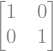

In [74]:
# Compute C = Q^T Q
C = sp.expand(QT * Q)

# Enforce algebraic identity
#C = C.replace(Delta**2, ((a-c)/2)**2 + b**2)

# Final cleanup
C = sp.simplify(C)
# C = sp.expand(C)
# C = sp.simplify(C)

C

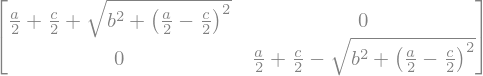

In [75]:
Lambda

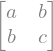

In [76]:
AA = sp.expand(Q * Lambda * QT)

# # Enforce algebraic identity
# AA = AA.replace(Delta**2, ((a-c)/2)**2 + b**2)

# # Final cleanup
AA = sp.simplify(AA)

AA

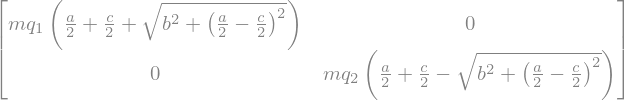

In [122]:
Lambda2 = sp.Matrix([
      [mq1 * q1 , 0],
      [0, mq2 * q2]
    ])

Lambda2

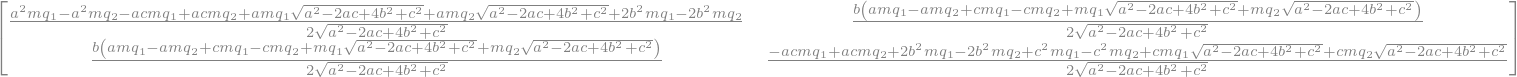

In [123]:
AA2 = sp.expand(Q * Lambda2 * QT)

# # Enforce algebraic identity
# AA = AA.replace(Delta**2, ((a-c)/2)**2 + b**2)

# # Final cleanup
AA2 = sp.simplify(AA2)

AA2

In [124]:
AA2[0,1] - AA2[1,0]

In [117]:
a1x, a1y, a2x, a2y, mp, l, m = sp.symbols('a1x a1y a2x a2y mp l m ', real=True)
replacements = {
    a: (2*a1x - a2y)/3,
    b: (a2x + a1y)/2,
    c: (-a1x+2*a2y)/3
}

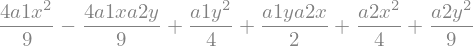

In [104]:
test = (a**2 + b**2).subs(replacements)
test = sp.expand(test)
test


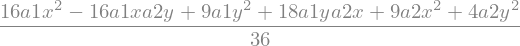

In [107]:
test = sp.factor(test)
test

In [111]:
p = sp.Poly(test, a1x)

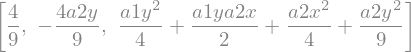

In [113]:
p.coeffs()

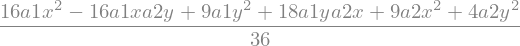

In [114]:
test

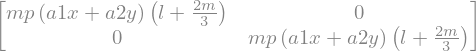

In [119]:
m_pres = sp.Matrix([
    [mp*(l+2*m/3)*(a1x+a2y), 0 ],
    [0, mp*(l+2*m/3)*(a1x+a2y) ]
    ])
m_pres

In [128]:
AA2b = AA2.subs(replacements)
#sp.simplify(AA2b)
sigma = m_pres + AA2b

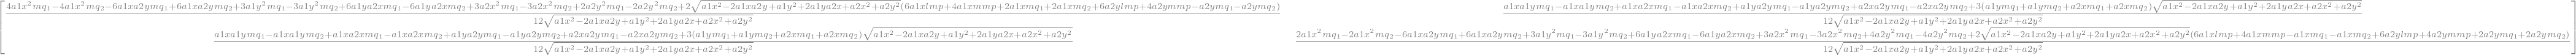

In [130]:
sigma = sp.expand(sigma)
sigma = sp.simplify(sigma)
sigma

In [136]:
abar, bbar, epsilon = sp.symbols('abar bbar epsilon', real=True)

pert={
    a : abar + epsilon*a,
    b : bbar + epsilon*b
    }

expr = (b*a**2).subs(pert)

In [142]:
display(expr)
display(sp.diff(expr,epsilon))
sp.diff(expr,epsilon).subs(epsilon,0)